In [1]:
!pip install -qqq torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 74.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 73.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 1.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 34.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 14.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 84.2 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installe

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data

from torchvision.io import read_image
from torchmetrics.functional import structural_similarity_index_measure as ssim

import os
import random

In [3]:
class Normalize(nn.Module):
    def __init__(self, upper_val = 255.0):
        super().__init__()
        self.upper_val = upper_val

    @torch.no_grad()
    def forward(self, image: torch.tensor, target: torch.tensor):
        return (
            image.float() / self.upper_val,
            target.float() / self.upper_val
        )
    
    def __repr__(self):
        return f"Divide all pixels in image by: {self.upper_val}"

In [4]:
class EncoderBlock(nn.Module):
    def __init__(
        self, 
        image_dim: int, 
        in_channels: int, 
        out_channels: int, 
        kernel_size: int, 
        non_linearity: nn.Module,
        downsample: bool = True
    ):
        super().__init__()
        self.image_dim = image_dim
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size

        self.conv1 = nn.Conv2d(
            in_channels=self.in_channels, 
            out_channels=self.out_channels, 
            kernel_size=kernel_size, 
            padding=1
        )
        self.pool = nn.MaxPool2d(kernel_size=2)
        self.non_linearity = non_linearity()
        self.bn = nn.BatchNorm2d(self.out_channels)
        self.conv2 = nn.Conv2d(
            in_channels=self.out_channels, 
            out_channels=self.out_channels, 
            kernel_size=kernel_size, 
            padding=1
        )

        if downsample:
            self.identity = nn.Sequential(
                self.pool,
                nn.Conv2d(
                    in_channels=self.in_channels,
                    out_channels=self.out_channels,
                    kernel_size=self.kernel_size,
                    padding=1
                )
            )
        else:
            self.identity = nn.Identity()

    def forward(self, x: torch.tensor):
        if x.shape[-1] != self.image_dim and x.shape[-2] != self.image_dim:
            raise ValueError(f"Tensor of invalid size: {x.shape} passed into Encoder block")

        xres = self.identity(x)
        xout1 = self.bn(self.non_linearity(self.conv1(x)))
        xout2 = self.pool(self.non_linearity(self.conv2(xout1)))
        return xout2 + xres
    

class DecoderBlock(nn.Module):
    def __init__(
        self, 
        image_dim: int, 
        in_channels: int, 
        out_channels: int, 
        kernel_size: int, 
        non_linearity: nn.Module,
        upsample: bool = True
    ):
        super().__init__()
        self.image_dim = image_dim
        self.in_channels = in_channels
        self.out_channels = out_channels 
        self.kernel_size = kernel_size

        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv1 = nn.Conv2d(
            in_channels=self.in_channels,
            out_channels=self.out_channels,
            kernel_size=self.kernel_size,
            padding=1
        )
        self.non_linearity = non_linearity()
        self.bn = nn.BatchNorm2d(self.out_channels)
        self.conv2 = nn.Conv2d(
            in_channels=self.out_channels,
            out_channels=self.out_channels,
            kernel_size=self.kernel_size,
            padding=1
        )

        if upsample:
            self.identity = nn.Sequential(
                nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
                nn.Conv2d(
                    in_channels=self.in_channels,
                    out_channels=self.out_channels,
                    kernel_size=self.kernel_size,
                    padding=1
                )
            )
        else:
            self.identity = nn.Identity()

    def forward(self, x: torch.tensor, skip_channel: torch.tensor = None):
        if x.shape[-1] != self.image_dim or x.shape[-2] != self.image_dim:
            raise ValueError(f"x with invalid shape: {x.shape} provided, expected last 2 dimensions: {self.image_dim}")

        if skip_channel is not None:
            if skip_channel.shape[-1] != self.image_dim or skip_channel.shape[-2] != self.image_dim:
                raise ValueError(f"Skip channel with invalid shape: {skip_channel.shape} provided, expected last 2 dimensions: {self.image_dim}")

            try:
                assert x.shape == skip_channel.shape
            except AssertionError:
                print("Shapes of input tensor and skip channel given to Decoder block are not same.")
                print(f"Shape of x: {x.shape}, Shape of skip channel: {skip_channel.shape}")

            x = torch.cat((x, skip_channel), axis=1)
            
        xres = self.identity(x)
        x = self.upsample(x)
        xout1 = self.bn(self.non_linearity(self.conv1(x)))
        xout2 = self.non_linearity(self.conv2(xout1))
        return xout2 + xres



class UNet(nn.Module):
    def __init__(
        self, 
        input_dim: int, 
        output_dim: int, 
        channels: list[int],
        skip_channels: bool = True
    ):
        super().__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.channels = channels

        self.encoder = nn.ModuleList()
        current_img_dim = self.input_dim
        prev_channel = 1
        for i in range(len(channels)):
            self.encoder.append(
                EncoderBlock(
                    image_dim=current_img_dim,
                    in_channels=prev_channel,
                    out_channels=channels[i],
                    kernel_size=3,
                    non_linearity=nn.ReLU,
                    downsample=True
                )
            )
            current_img_dim /= 2
            prev_channel = channels[i]

        self.decoder = nn.ModuleList()
        channels.reverse()
        channels = channels[1:]
        channels.append(1)
        for i in range(len(channels)):
            self.decoder.append(
                DecoderBlock(
                    image_dim=current_img_dim,
                    in_channels=prev_channel if not skip_channels else prev_channel*2,
                    out_channels=channels[i],
                    kernel_size=3,
                    non_linearity=nn.ReLU,
                    upsample=True
                )
            )
            current_img_dim *= 2
            prev_channel = channels[i]

        del prev_channel, current_img_dim

        self.final_conv = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=1)

    def forward(self, x: torch.tensor):
        if x.shape[-1] != self.input_dim or x.shape[-2] != self.input_dim:
            raise ValueError(f"Expected last 2 dimensions of x.shape: {self.input_dim}, recieved: {x.shape}") 
        
        xout = x
        layer_outputs = []

        for encoder_block in self.encoder:
            xout = encoder_block(xout)
            layer_outputs.append(xout)

        reversed_layer_outputs = list(reversed(layer_outputs))
        for i, decoder_block in enumerate(self.decoder):
            xout = decoder_block(xout, reversed_layer_outputs[i])

        return self.final_conv(xout)

In [5]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')
MSELoss = nn.MSELoss()

Using device: cuda


In [6]:
model1 = UNet(
    input_dim=256,
    output_dim=256,
    channels=[8, 16, 32, 64, 128]
)

model1.load_state_dict(torch.load('/kaggle/input/model/pytorch/default/1/model-epoch99.pth', map_location=torch.device('cpu')))
modelg1 = model1.to(device=device)

total_trainable = sum(p.numel() for p in model1.parameters() if p.requires_grad)
print(f"Trainable parameters in model1: {total_trainable}")

Trainable parameters in model1: 835184


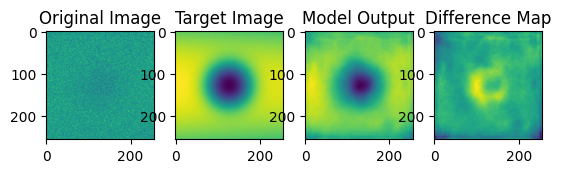

In [7]:
import matplotlib.pyplot as plt
img1 = read_image('/kaggle/input/phasedatagen/data/test/images/image-102-snr--4.396984924623116.png')
label1 = read_image('/kaggle/input/phasedatagen/data/test/labels/target-102-snr--4.396984924623116.png')

norm_object = Normalize()
img1_in, label1_in = norm_object(img1, label1)

modelout = modelg1(img1_in.float().unsqueeze(0).to(device))

diffmap = (modelout - label1_in.to(device)) / (torch.max(modelout).to(device) - torch.min(modelout).to(device))
modelout = modelout.cpu().detach().numpy()
diffmap = diffmap.cpu().detach().numpy()

fig, axes = plt.subplots(1, 4)
axes[0].imshow(img1[0])
axes[0].set_title('Original Image')
axes[1].imshow(label1[0])
axes[1].set_title('Target Image')
axes[2].imshow(modelout[0][0])
axes[2].set_title('Model Output')
axes[2].imshow(modelout[0][0])
axes[2].set_title('Model Output')
axes[3].imshow(diffmap[0][0])
axes[3].set_title('Difference Map')
plt.show()

In [32]:
mse_losses = {}
ssim_losses = {}
snr_outs = {}
count = {}

norm_object = Normalize()

with torch.no_grad():
    for f in os.listdir('/kaggle/input/phasedatagen/data/test/images'):
        target_snr = float(f.split("snr-")[-1].split(".png")[0])
        target_name = f.replace('image', 'target')
        target_img = f'/kaggle/input/phasedatagen/data/test/labels/{target_name}'
        noisy = read_image('/kaggle/input/phasedatagen/data/test/images/' + f).unsqueeze(0)
        noisy = noisy.to(device)
        label = read_image(target_img).to(device)
        nosiy_n, label_n = norm_object(noisy, label)
        modelout = modelg1(nosiy_n.float())
        mse_loss = MSELoss(modelout[0], label_n.float())
        mse_losses[target_snr] = mse_losses.get(target_snr, 0) + mse_loss
        snr_out = -10*torch.log10(mse_loss)
        snr_outs[target_snr] = snr_outs.get(target_snr, 0) + snr_out
        count[target_snr] = count.get(target_snr, 0) + 1
        ssim_loss = ssim(modelout, label_n.unsqueeze(0))
        ssim_losses[target_snr] = ssim_losses.get(target_snr, 0) + ssim_loss

In [34]:
with torch.no_grad():
    for k in count.keys():
        mse_losses[k] = mse_losses[k] / count[k]
        ssim_losses[k] = ssim_losses[k] / count[k]
        snr_outs[k] = snr_outs[k] / count[k]

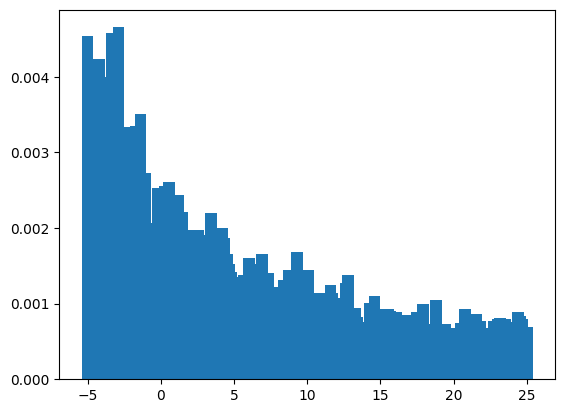

In [27]:
v = [t.cpu().detach() for t in mse_losses.values()]

plt.bar(count.keys(), v)
plt.show()

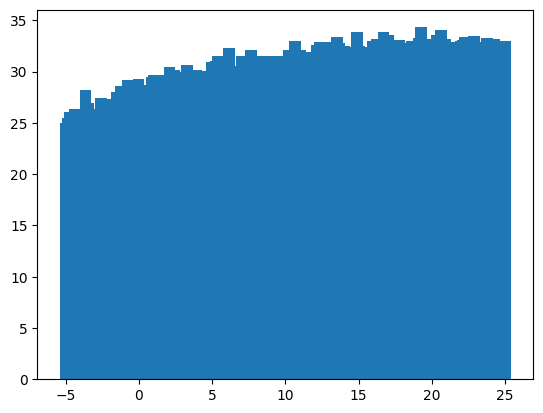

In [29]:
v = [t.cpu().detach() for t in snr_outs.values()]

plt.bar(count.keys(), v)
plt.show()

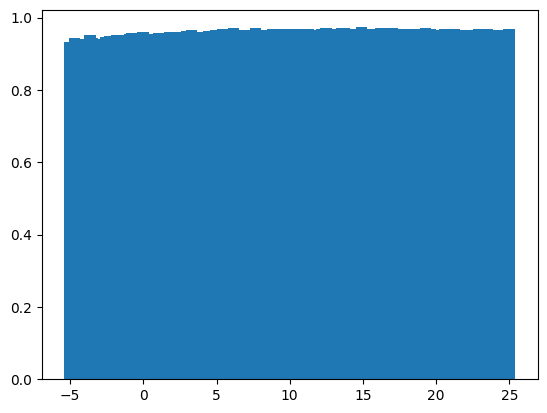

In [35]:
v = [t.cpu().detach() for t in ssim_losses.values()]

plt.bar(count.keys(), v)
plt.show()